Temps d'execution :  3.776111602783203


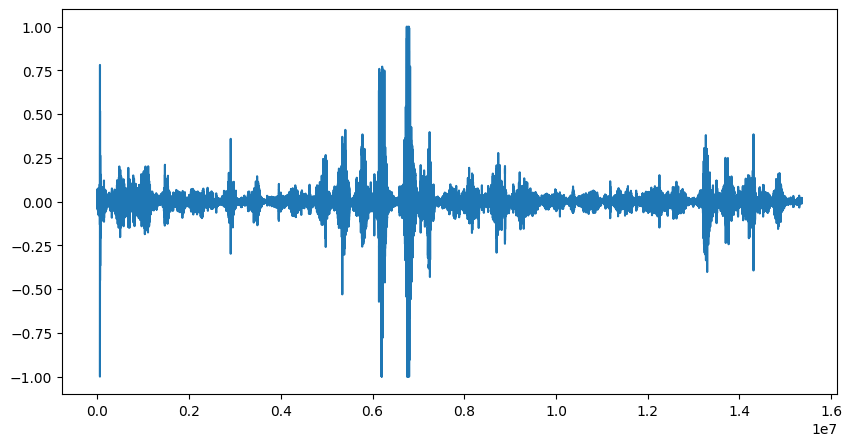

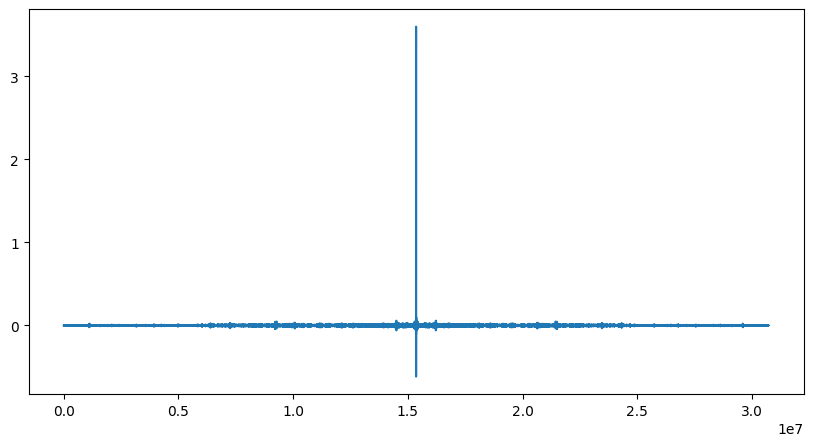

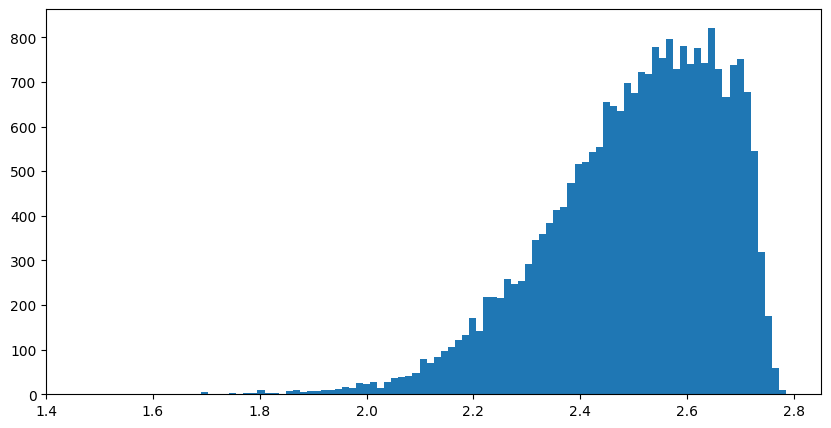

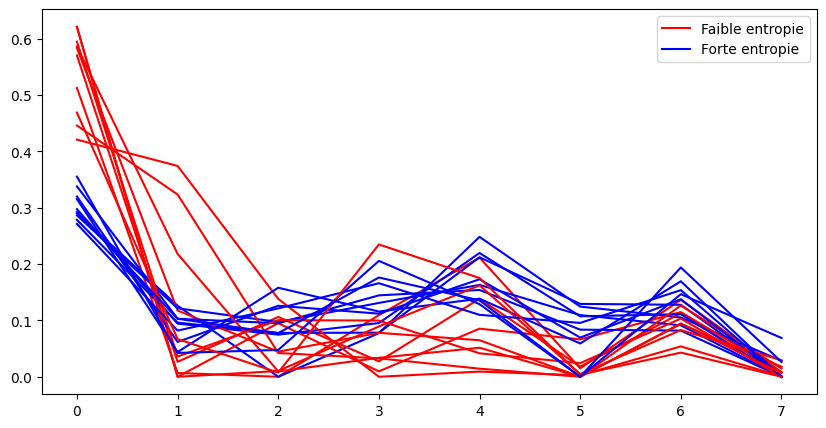

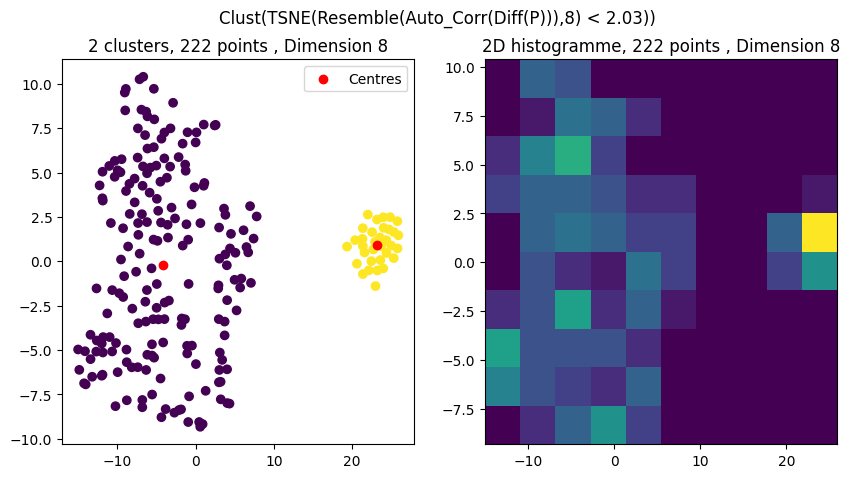

In [1]:
import soundfile as sf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy import signal
from scipy.signal import resample
import scipy
import os
from sklearn.manifold import TSNE
# import umap
import warnings
import time


debut = time.time()
 
 #Code Flo
 
 
warnings.filterwarnings("ignore", category=FutureWarning)
 
 
def save_file(save_list: list, folder_path="data", add_folder_by_name=False):
	if not isinstance(save_list, list):
		raise ValueError("save_list must be a list")
	if len(save_list) == 0:
		raise ValueError("save_list must not be empty")
 
	def decorateur(func):
		def wrapper(*args, **kwargs):
			full_path = os.path.join(folder_path)
			if add_folder_by_name:
				full_path = os.path.join(full_path, kwargs["filename"])
			full_path_list = [
				os.path.join(full_path, f"{save_file}.npy") for save_file in save_list
			]
			if all(os.path.exists(save_file) for save_file in full_path_list):
				return [
					np.load(save_file, allow_pickle=True)
					for save_file in full_path_list
				]
			res = func(*args, **kwargs)
			os.makedirs(os.path.dirname(full_path_list[0]), exist_ok=True)
			for save_elment, save_path in zip(res, full_path_list):
				np.save(save_path, save_elment)
			return res
 
		return wrapper
 
	return decorateur
 
 
@save_file(["data", "diff"])
def get_data():
	data = []
	fichiers = os.listdir('Audios')
	print(fichiers)
	for f in fichiers[20:25] :
		d, r = sf.read(f"Audios/{f}")
		print(f)
		data = np.concatenate((data,d))
	diff = np.zeros(len(data))
	print(len(data))
	for i in range(0, len(data) - 1):
		diff[i] = data[i + 1] - data[i]
	return data, diff


data, diff = get_data()
fig, ax = plt.subplots(figsize=(10, 5))
_ = ax.plot(data)
fig, ax = plt.subplots(figsize=(10, 5))
_ = ax.plot(signal.correlate(diff, diff))
 
 
 
def entropie(p):
	return -sum(p * np.log2(p))
 
 
@save_file(["corr", "entropie"], add_folder_by_name=True)
def get_matrix(filename, step=1280, resample_final=8):
	data, diff = get_data(filename)
	corr = []
	entropie_mat = []
	for half_step in range(0, (len(diff)), (step // 2)):
		tmp_diff = diff[half_step : half_step + step]
		auto_corr = signal.correlate(tmp_diff, tmp_diff)
 
		auto_corr = np.array(auto_corr[len(auto_corr) // 2 : len(auto_corr) // 2 + 128])
		auto_corr = resample(auto_corr, resample_final)
 
		auto_corr = auto_corr - min(auto_corr) + 10**-20
		auto_corr = auto_corr / sum(auto_corr)
 
		entropie_mat.append(entropie(auto_corr))
		corr.append(auto_corr)
 
	corr = np.array(corr)
	entropie_mat = np.array(entropie_mat)
	return corr, entropie_mat
 
 
corr, entropie_mat = get_matrix(filename="file1")
fig, ax = plt.subplots(figsize=(10, 5))
n = 100
_ = ax.hist(entropie_mat, n)
# _ = ax1.set_title(f"Hist(Ent(Resample(Auto_Corr(Diff(P)),{resample_final})),{n})")
 
# entropie_weak_bias = 6.8
# entropie_strong_bias = 6.85
# entropie_weak_bias = 4.38
# entropie_strong_bias 4.75
entropie_weak_bias = 2.03
entropie_strong_bias = 2.25
 
weak_entropie = corr[np.where(entropie_mat < entropie_weak_bias)]
strong_entropie = corr[np.where(entropie_mat > entropie_strong_bias)]
weak_entropie_value = entropie_mat[np.where(entropie_mat < entropie_weak_bias)]
# weak_entropie = no_change[np.where(entropie_mat < 4.38)]
# strong_entropie = no_change[np.where(entropie_mat > 4.75)]
 
 
fig, ax = plt.subplots(figsize=(10, 5))
# ax2.set_title("Correlation")
for i in range(0, 10):
	_ = ax.plot(weak_entropie[i], "r")
	_ = ax.plot(strong_entropie[i], "b")
red_line = Line2D([0], [0], color="r")
blue_line = Line2D([0], [0], color="b")
_ = ax.legend([red_line, blue_line], ["Faible entropie", "Forte entropie"])
 
# weak_entropie = np.array(
#     sorted(weak_entropie, key=lambda x: x.mean())[0 : len(weak_entropie) // 2]
# )
 
def plot_scatter_hist2d(data, labels, cluster_centers, dimension, title=""):
	fig = plt.figure(figsize=(10, 5))
	fig.suptitle(title)
	ax1 = fig.add_subplot(121)
	ax2 = fig.add_subplot(122)
	scatter = ax1.scatter(
		data[:, 0],
		data[:, 1],
		c=labels,
		# label="Données clusterisées",
	)
	if len(set(labels)) > 6:
		_ = fig.colorbar(scatter, ax=ax1)
 
	_ = ax1.scatter(
		cluster_centers[:, 0], cluster_centers[:, 1], c="r", label="Centres"
	)
	_ = ax1.set_title(f"2 clusters, {len(data)} points , Dimension {dimension}")
	_ = ax1.legend()
 
	_ = ax2.hist2d(data[:, 0], data[:, 1])
	_ = ax2.set_title(f"2D histogramme, {len(data)} points , Dimension {dimension}")
 
tsne = TSNE(n_components=2, random_state=0, perplexity=30, max_iter=1000)
weak_entropie_2d = tsne.fit_transform(weak_entropie)
 
codebook, _ = scipy.cluster.vq.kmeans(weak_entropie_2d, 2)
labels, _ = scipy.cluster.vq.vq(weak_entropie_2d, codebook)
 
plot_scatter_hist2d(
	weak_entropie_2d,
	labels,
	codebook,
	len(weak_entropie[0]),
	f"Clust(TSNE(Resemble(Auto_Corr(Diff(P))),{len(weak_entropie[0])}) < {entropie_weak_bias}))",
)

print("Temps d'execution : ", time.time() - debut)
 
plt.show()